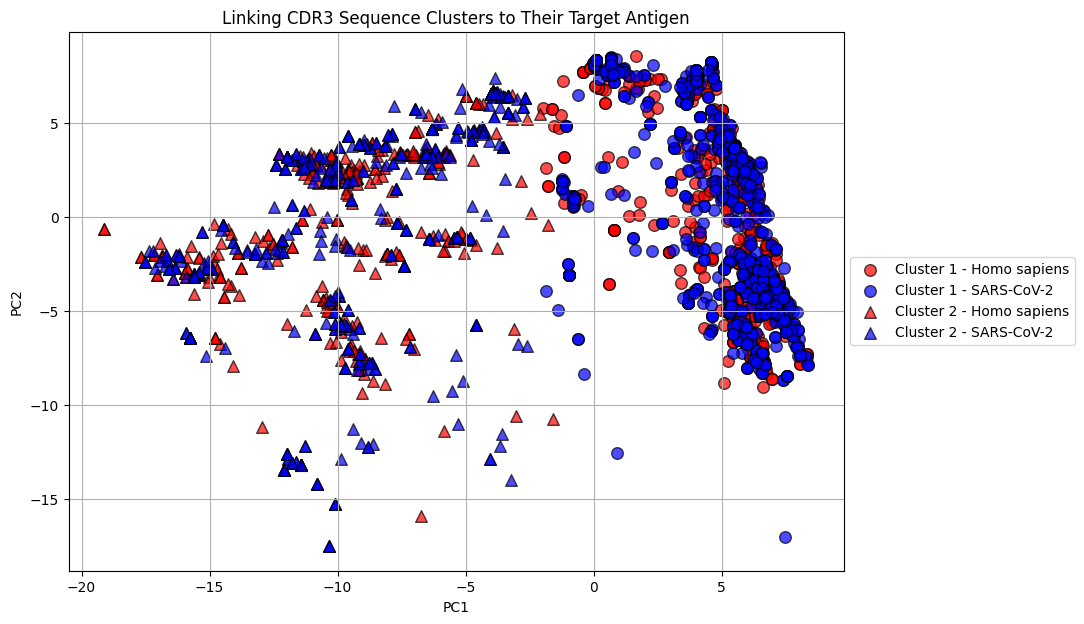

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("CDR3_pca_clusters_final.csv")

# Normalize antigen species strings
df['antigen_species'] = df['antigen_species'].str.lower().str.strip()

# Define color mapping for antigens
color_map = {
    'homo sapiens': 'red',
    'severe acute respiratory syndrome coronavirus2': 'blue'
}

# Define marker mapping for clusters 
marker_map = {
    0: 'o',  # cluster 1
    1: '^'   # cluster 2
}

# Map colors and markers
df['color'] = df['antigen_species'].map(color_map)
df['marker'] = df['Cluster'].map(marker_map)


df = df.dropna(subset=['color', 'marker'])

plt.figure(figsize=(10, 7))

# Plot each cluster/antigen combo
for cluster in df['Cluster'].unique():
    cluster_label = cluster + 1  # Shift label 0→1, 1→2
    for antigen in df['antigen_species'].unique():
        subset = df[(df['Cluster'] == cluster) & (df['antigen_species'] == antigen)]
        if subset.empty:
            continue
        plt.scatter(
            subset['PC1'], subset['PC2'],
            c=color_map[antigen],
            marker=marker_map[cluster],
            label=f'Cluster {cluster_label}, Antigen {antigen}',
            alpha=0.7,
            edgecolors='k',
            s=70
        )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Linking CDR3 Sequence Clusters to Their Target Antigen')
plt.legend(loc='best')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
import matplotlib.pyplot as plt



handles, labels = plt.gca().get_legend_handles_labels()

new_labels = [
    "Cluster 1 - Homo sapiens",
    "Cluster 1 - SARS-CoV-2",
    "Cluster 2 - Homo sapiens",
    "Cluster 2 - SARS-CoV-2"
]


plt.legend(handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()


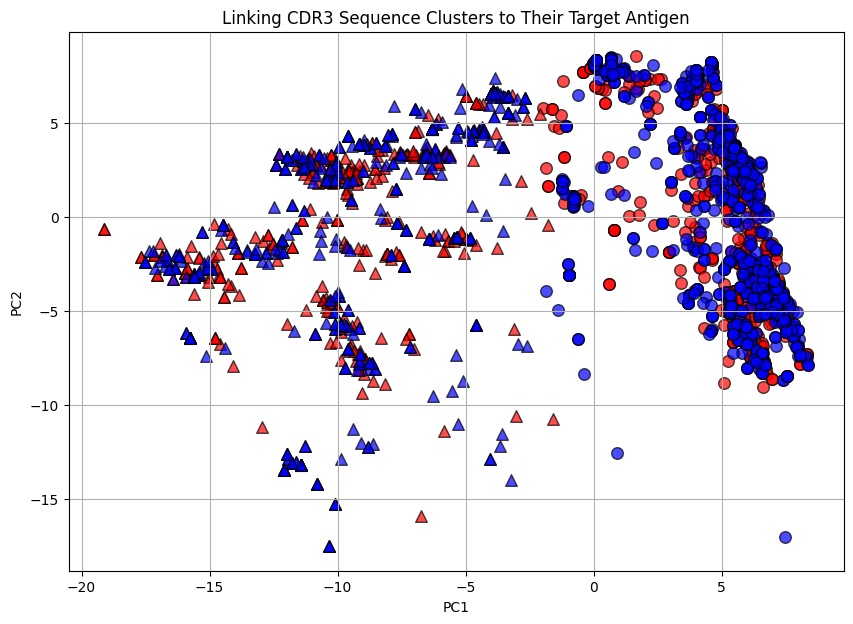

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("CDR3_pca_clusters_final.csv")

# Normalize antigen species strings
df['antigen_species'] = df['antigen_species'].str.lower().str.strip()

# Define color mapping for antigens
color_map = {
    'homo sapiens': 'red',
    'severe acute respiratory syndrome coronavirus2': 'blue'
}

# Define marker mapping for clusters 
marker_map = {
    0: 'o',  # cluster 1
    1: '^'   # cluster 2
}

# Map colors and markers
df['color'] = df['antigen_species'].map(color_map)
df['marker'] = df['Cluster'].map(marker_map)


df = df.dropna(subset=['color', 'marker'])

plt.figure(figsize=(10, 7))

# Plot each cluster/antigen combo
for cluster in df['Cluster'].unique():
    cluster_label = cluster + 1  # Shift label 0→1, 1→2
    for antigen in df['antigen_species'].unique():
        subset = df[(df['Cluster'] == cluster) & (df['antigen_species'] == antigen)]
        if subset.empty:
            continue
        plt.scatter(
            subset['PC1'], subset['PC2'],
            c=color_map[antigen],
            marker=marker_map[cluster],
            label=f'Cluster {cluster_label}, Antigen {antigen}',
            alpha=0.7,
            edgecolors='k',
            s=70
        )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Linking CDR3 Sequence Clusters to Their Target Antigen')

plt.grid(True)



plt.show()


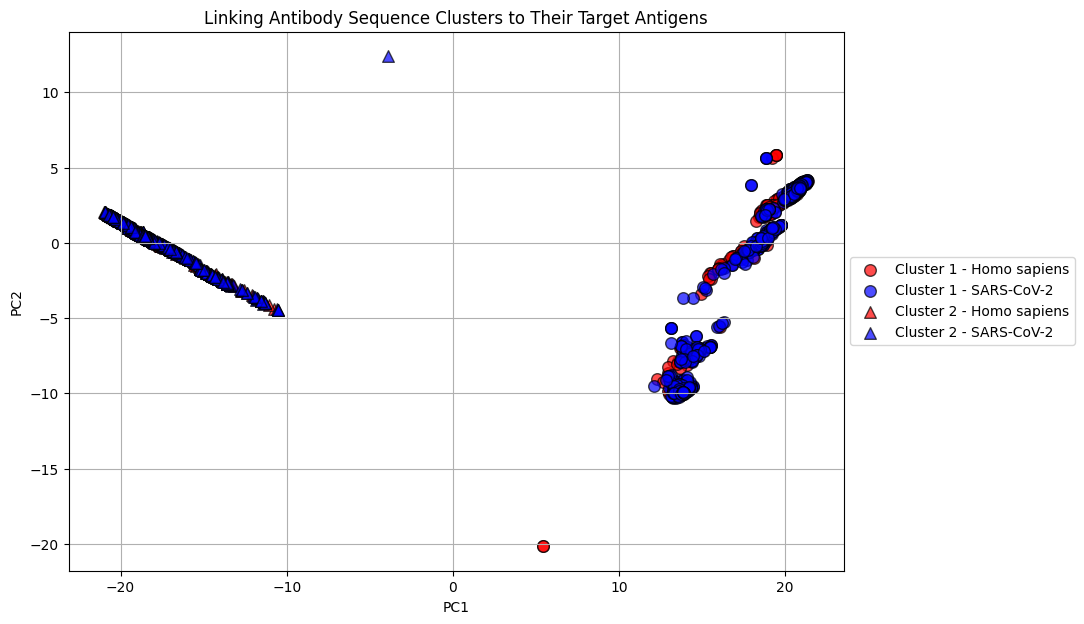

In [34]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("antibodies_pca_clusters.csv")

df['antigen_species'] = df['Unnamed: 0'].str.extract(r'antigen_species=([^,|]+)')
df['antigen_species'] = df['antigen_species'].str.lower().str.strip()
df['antigen_species'] = df['antigen_species'].replace({'homo': 'homo sapiens'})


# Normalize and fix antigen_species names
df['antigen_species'] = df['antigen_species'].str.lower().str.strip()
df['antigen_species'] = df['antigen_species'].replace({'homo': 'homo sapiens'})

# Define color and marker mappings
color_map = {
    'homo sapiens': 'red',
    'severe': 'blue'
}
marker_map = {0: 'o', 1: '^'}

# Map colors and markers
df['color'] = df['antigen_species'].map(color_map)
df['marker'] = df['Cluster'].map(marker_map)
df = df.dropna(subset=['color', 'marker'])

plt.figure(figsize=(10, 7))

used_labels = set()

for cluster in df['Cluster'].unique():
    cluster_label = cluster + 1
    for antigen in df['antigen_species'].unique():
        subset = df[(df['Cluster'] == cluster) & (df['antigen_species'] == antigen)]
        if subset.empty:
            continue
        label = f'Cluster {cluster_label} - {antigen.title()}'
        if label in used_labels:
            label = None
        else:
            used_labels.add(label)
        plt.scatter(
            subset['PC1'], subset['PC2'],
            c=color_map[antigen],
            marker=marker_map[cluster],
            label=label,
            alpha=0.7,
            edgecolors='k',
            s=70
        )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title("Linking Antibody Sequence Clusters to Their Target Antigens")
plt.grid(True)


new_labels = [
    "Cluster 1 - Homo sapiens",
    "Cluster 1 - SARS-CoV-2",
    "Cluster 2 - Homo sapiens",
    "Cluster 2 - SARS-CoV-2"
]


plt.legend(handles, new_labels, loc='center left', bbox_to_anchor=(1, 0.5))


plt.show()


plt.show()
